In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score

In [64]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head(3)

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes


In [65]:
x = df.drop(columns='Loan_Approved')
y = df['Loan_Approved']

In [66]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

In [67]:
cat_cols = x.select_dtypes(include='object').columns
df[cat_cols].nunique()
num_cols = x.select_dtypes(include='number').columns
num_cols


C:\Users\HP\AppData\Local\Temp\ipykernel_26820\1023416475.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include='object').columns


Index(['Age', 'Salary', 'Credit_Score', 'Loan_Amount'], dtype='str')

<Axes: >

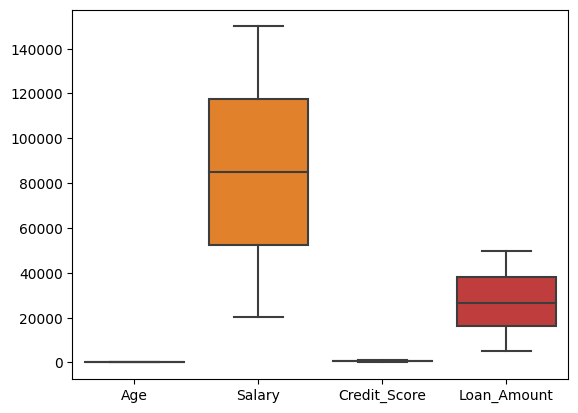

In [68]:
sns.boxplot(df[num_cols])

In [69]:
preprocessing = ColumnTransformer(transformers=[
    ('scaling', MinMaxScaler(), num_cols),
    ('encoder', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [70]:
main_pipeline = Pipeline(
    steps=[('pre_processing', preprocessing),
             ('model', LogisticRegression())]
)
main_pipeline.fit(xtrain, ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre_processing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

##### check which penalties supports which solvers

penalty -   solver

L1      -   liblinear, saga

L2      -   lbfgs, liblinear, sag, saga

elasticnet - saga

None     - lbfgs, sag, saga


In [71]:
# for sentence based classification use sag and saga

# Classification metrics

#### confusion metrics

In [72]:
# train data

ytrain_pred = main_pipeline.predict(xtrain)
cm_train = confusion_matrix(ytrain, ytrain_pred)
print(cm_train)

[[205 192]
 [170 233]]


In [73]:
ytest.value_counts()

Loan_Approved
Yes    105
No      95
Name: count, dtype: int64

In [74]:
# test data
ytest_pred = main_pipeline.predict(xtest)
cm_test = confusion_matrix(ytest, ytest_pred)
print(cm_test)

[[47 48]
 [53 52]]


### precision score

In [75]:
# train data
print(precision_score(ytrain, ytrain_pred, pos_label='Yes'))

0.548235294117647


In [76]:
cm_train[:, 1].sum()

425

##### out of all the predicted (425) Yes label, 54% labels are correctly predicted as Yes
##### out of all the predicted (425) Yes label, remaining 46% labels are falsely predicted as Yes

In [77]:
print(precision_score(ytrain, ytrain_pred, pos_label='No'))

0.5466666666666666


In [78]:
cm_train[:, 0].sum()

375

##### out of all the predicted (375) No label, 54% labels are correctly predicted as No
##### out of all the predicted (375) No label, remaining 46% labels are falsely predicted as No


In [79]:
# test data
print(precision_score(ytest, ytest_pred, pos_label='Yes'))
print(precision_score(ytest, ytest_pred, pos_label='No'))

0.52
0.47


In [84]:
print(cm_test[:, 1].sum())
print(cm_test[:, 0].sum())

100
100


##### out of all the predicted (100) No label, 47% labels are correctly predicted as No
##### out of all the predicted (100) No label, 53% labels are falsely predicted as No

##### out of all the predicted (100) Yes label, 52% labels are correctly predicted as Yes
##### out of all the predicted (100) Yes label, 48% labels are falsely predicted as Yes


### recall score

In [80]:
print(recall_score(ytrain, ytrain_pred, pos_label='Yes'))
print(recall_score(ytrain, ytrain_pred, pos_label='No'))

0.5781637717121588
0.5163727959697733


In [81]:
print(recall_score(ytest, ytest_pred, pos_label='Yes'))
print(recall_score(ytest, ytest_pred, pos_label='No'))

0.49523809523809526
0.49473684210526314


### accuracy score

In [82]:
print(accuracy_score(ytrain, ytrain_pred))
print(accuracy_score(ytest, ytest_pred))


0.5475
0.495
